In [171]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [177]:
import pandas as pd
import csv

file_path = '/content/movies_metadata(dataset1).csv'

# Loading the dataset without low_memory as it is incompatible with the python engine
try:
    df = pd.read_csv(file_path,
                     on_bad_lines='skip',
                     engine='python',
                     quoting=csv.QUOTE_MINIMAL)
    print(f'Successfully loaded dataset with shape: {df.shape}')
    display(df.head())
except Exception as e:
    print(f'Error loading file: {e}')

Successfully loaded dataset with shape: (7657, 24)


,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",...,1995-10-30,373554033,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415
1,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,...,1995-12-15,262797249,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413
2,False,"{'id': 119050, 'name': 'Grumpy Old Men Collect...",0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",NaN,15602,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,...,1995-12-22,0,101.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Still Yelling. Still Fighting. Still Ready for...,Grumpier Old Men,False,6.5,92
3,False,NaN,16000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,31357,tt0114885,en,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",...,1995-12-22,81452156,127.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Friends are the people who let you be yourself...,Waiting to Exhale,False,6.1,34
4,False,"{'id': 96871, 'name': 'Father of the Bride Col...",0,"[{'id': 35, 'name': 'Comedy'}]",NaN,11862,tt0113041,en,Father of the Bride Part II,Just when George Banks has recovered from his ...,...,1995-02-10,76578911,106.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Just When His World Is Back To Normal... He's ...,Father of the Bride Part II,False,5.7,173


In [173]:
if 'df' in locals():
    print("DataFrame Info:")
    df.info()
    print("\nDataFrame Shape:")
    display(df.shape)
else:
    print("DataFrame 'df' is not defined. Please run the data loading cell first.")

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
Index: 7651 entries, 0 to 7656
Data columns (total 25 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   adult                  7651 non-null   bool   
 1   belongs_to_collection  1134 non-null   object 
 2   budget                 7651 non-null   int64  
 3   genres                 7651 non-null   object 
 4   homepage               506 non-null    object 
 5   id                     7651 non-null   int64  
 6   imdb_id                7651 non-null   object 
 7   original_language      7651 non-null   object 
 8   original_title         7651 non-null   object 
 9   overview               7627 non-null   object 
 10  popularity             7651 non-null   float64
 11  poster_path            7620 non-null   object 
 12  production_companies   7651 non-null   object 
 13  production_countries   7651 non-null   object 
 14  release_date           7646 non-null   object

(7651, 25)

In [174]:
df.head()

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count,cleaned_genres
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",...,373554033,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415,"[Animation, Comedy, Family]"
1,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,...,262797249,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413,"[Adventure, Fantasy, Family]"
2,False,"{'id': 119050, 'name': 'Grumpy Old Men Collect...",0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",NaN,15602,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,...,0,101.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Still Yelling. Still Fighting. Still Ready for...,Grumpier Old Men,False,6.5,92,"[Romance, Comedy]"
3,False,NaN,16000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,31357,tt0114885,en,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",...,81452156,127.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Friends are the people who let you be yourself...,Waiting to Exhale,False,6.1,34,"[Comedy, Drama, Romance]"
4,False,"{'id': 96871, 'name': 'Father of the Bride Col...",0,"[{'id': 35, 'name': 'Comedy'}]",NaN,11862,tt0113041,en,Father of the Bride Part II,Just when George Banks has recovered from his ...,...,76578911,106.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Just When His World Is Back To Normal... He's ...,Father of the Bride Part II,False,5.7,173,[Comedy]


In [175]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

In [186]:
if 'df' in locals() and 'cleaned_genres' in df.columns:
    # Filter for Adventure genre and movies with revenue > 0
    adventure_rev = df[(df['cleaned_genres'].apply(lambda x: 'Adventure' in x)) & (df['revenue'] > 0)]

    # Sort by revenue descending and take top 10
    top_10_adventure_rev = adventure_rev.sort_values(by='revenue', ascending=False).head(10)

    print('Top 10 Highest-Grossing Adventure Movies:')
    display(top_10_adventure_rev[['title', 'revenue', 'vote_average', 'release_date']].style.format({'revenue': '${:,.0f}'}))
else:
    print('DataFrame or cleaned_genres column not found.')

Top 10 Highest-Grossing Adventure Movies:


,title,revenue,vote_average,release_date
7000,The Lord of the Rings: The Return of the King,"$1,118,888,979",8.100000,2003-12-01
4766,Harry Potter and the Philosopher's Stone,"$976,475,550",7.500000,2001-11-16
5814,The Lord of the Rings: The Two Towers,"$926,287,400",8.000000,2002-12-18
2514,Star Wars: Episode I - The Phantom Menace,"$924,317,558",6.400000,1999-05-19
475,Jurassic Park,"$920,100,000",7.600000,1993-06-11
5678,Harry Potter and the Chamber of Secrets,"$876,688,482",7.400000,2002-11-13
4863,The Lord of the Rings: The Fellowship of the Ring,"$871,368,364",8.000000,2001-12-18
760,Independence Day,"$816,969,268",6.700000,1996-06-25
1065,E.T. the Extra-Terrestrial,"$792,965,326",7.300000,1982-04-03
256,Star Wars,"$775,398,007",8.100000,1977-05-25


In [185]:
if 'df' in locals() and 'cleaned_genres' in df.columns:
    # Filter for Animation genre and movies with revenue > 0
    animation_rev = df[(df['cleaned_genres'].apply(lambda x: 'Animation' in x)) & (df['revenue'] > 0)]

    # Sort by revenue descending and take top 10
    top_10_anim_rev = animation_rev.sort_values(by='revenue', ascending=False).head(10)

    print('Top 10 Highest-Grossing Animation Movies:')
    display(top_10_anim_rev[['title', 'revenue', 'vote_average', 'release_date']].style.format({'revenue': '${:,.0f}'}))
else:
    print('DataFrame or cleaned_genres column not found.')

Top 10 Highest-Grossing Animation Movies:


,title,revenue,vote_average,release_date
6232,Finding Nemo,"$940,335,536",7.600000,2003-05-30
359,The Lion King,"$788,241,776",8.000000,1994-06-23
1003,Alice in Wonderland,"$572,000,000",7.000000,1951-07-03
4756,"Monsters, Inc.","$562,816,256",7.500000,2001-11-01
581,Aladdin,"$504,050,219",7.400000,1992-11-25
2997,Toy Story 2,"$497,366,869",7.300000,1999-10-30
4178,Shrek,"$484,409,218",7.300000,2001-05-16
2572,Tarzan,"$448,000,000",7.100000,1999-06-18
5084,Ice Age,"$383,257,136",7.100000,2002-03-10
588,Beauty and the Beast,"$377,350,553",7.500000,1991-11-13


In [184]:
if 'df' in locals() and 'cleaned_genres' in df.columns:
    # Filter for Animation genre
    animation_pop = df[df['cleaned_genres'].apply(lambda x: 'Animation' in x)]

    # Sort by popularity descending and take top 10
    top_10_animation = animation_pop.sort_values(by='popularity', ascending=False).head(10)

    print('Top 10 Most Popular Animation Movies:')
    display(top_10_animation[['title', 'popularity', 'vote_average', 'release_date']])
else:
    print('DataFrame or cleaned_genres column not found.')

Top 10 Most Popular Animation Movies:


,title,popularity,vote_average,release_date
5481,Spirited Away,41.048867,8.3,2001-07-20
4756,"Monsters, Inc.",26.419962,7.5,2001-11-01
6232,Finding Nemo,25.497794,7.6,2003-05-30
588,Beauty and the Beast,23.433511,7.5,1991-11-13
1969,The Jungle Book,22.845448,7.1,1967-10-17
0,Toy Story,21.946943,7.7,1995-10-30
359,The Lion King,21.605761,8.0,1994-06-23
1798,Mulan,21.180857,7.6,1998-06-18
5310,Lilo & Stitch,18.469238,7.1,2002-06-21
4178,Shrek,17.987728,7.3,2001-05-16


In [183]:
if 'df' in locals() and 'cleaned_genres' in df.columns:
    target_genres = ['Animation', 'Adventure', 'Fantasy']

    for genre in target_genres:
        # Filter for the specific genre and sort by revenue
        top_movies = df[df['cleaned_genres'].apply(lambda x: genre in x)].sort_values(by='revenue', ascending=False).head(5)

        print(f'\n--- Top 5 Highest-Grossing {genre} Movies ---')
        display(top_movies[['title', 'revenue', 'vote_average', 'release_date']].style.format({'revenue': '${:,.0f}'}))
else:
    print('DataFrame or cleaned_genres column not found.')


--- Top 5 Highest-Grossing Animation Movies ---


,title,revenue,vote_average,release_date
6232,Finding Nemo,"$940,335,536",7.600000,2003-05-30
359,The Lion King,"$788,241,776",8.000000,1994-06-23
1003,Alice in Wonderland,"$572,000,000",7.000000,1951-07-03
4756,"Monsters, Inc.","$562,816,256",7.500000,2001-11-01
581,Aladdin,"$504,050,219",7.400000,1992-11-25



--- Top 5 Highest-Grossing Adventure Movies ---


,title,revenue,vote_average,release_date
7000,The Lord of the Rings: The Return of the King,"$1,118,888,979",8.100000,2003-12-01
4766,Harry Potter and the Philosopher's Stone,"$976,475,550",7.500000,2001-11-16
5814,The Lord of the Rings: The Two Towers,"$926,287,400",8.000000,2002-12-18
2514,Star Wars: Episode I - The Phantom Menace,"$924,317,558",6.400000,1999-05-19
475,Jurassic Park,"$920,100,000",7.600000,1993-06-11



--- Top 5 Highest-Grossing Fantasy Movies ---


,title,revenue,vote_average,release_date
7000,The Lord of the Rings: The Return of the King,"$1,118,888,979",8.100000,2003-12-01
4766,Harry Potter and the Philosopher's Stone,"$976,475,550",7.500000,2001-11-16
5814,The Lord of the Rings: The Two Towers,"$926,287,400",8.000000,2002-12-18
5678,Harry Potter and the Chamber of Secrets,"$876,688,482",7.400000,2002-11-13
4863,The Lord of the Rings: The Fellowship of the Ring,"$871,368,364",8.000000,2001-12-18


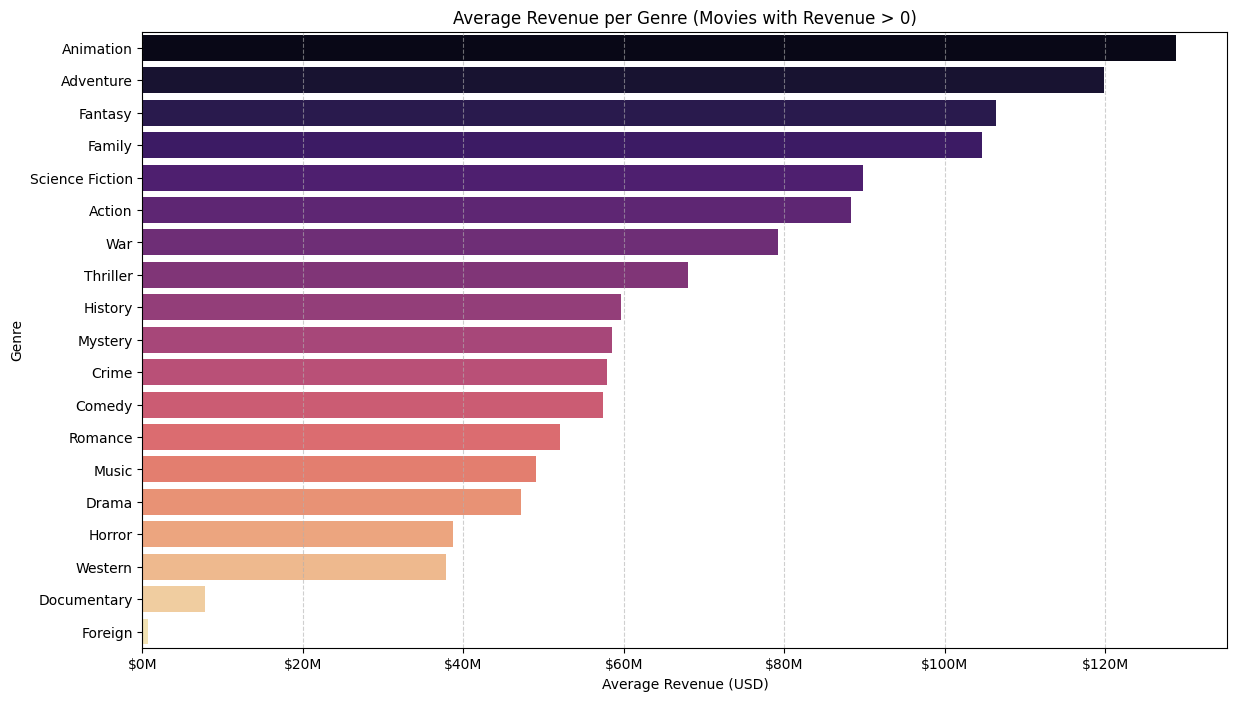

Revenue Summary per Genre:


,Genre,Average Revenue
2,Animation,"$128,808,965"
1,Adventure,"$119,925,678"
8,Fantasy,"$106,365,517"
7,Family,"$104,676,211"
15,Science Fiction,"$89,780,628"
0,Action,"$88,296,341"
17,War,"$79,278,478"
16,Thriller,"$68,049,795"
10,History,"$59,655,882"
13,Mystery,"$58,476,392"


In [182]:
import matplotlib.pyplot as plt
import seaborn as sns

if 'df' in locals() and 'cleaned_genres' in df.columns:
    # Filter for movies with recorded revenue > 0 and explode by genre
    revenue_df = df[df['revenue'] > 0].explode('cleaned_genres')

    # Calculate average revenue per genre
    genre_revenue = revenue_df.groupby('cleaned_genres')['revenue'].mean().reset_index()
    genre_revenue.columns = ['Genre', 'Average Revenue']
    genre_revenue = genre_revenue.sort_values(by='Average Revenue', ascending=False)

    # Visualization
    plt.figure(figsize=(14, 8))
    sns.barplot(data=genre_revenue, x='Average Revenue', y='Genre', palette='magma')
    plt.title('Average Revenue per Genre (Movies with Revenue > 0)')
    plt.xlabel('Average Revenue (USD)')
    plt.ylabel('Genre')

    # Format x-axis to be more readable
    from matplotlib.ticker import FuncFormatter
    def millions(x, pos):
        return f'${x*1e-6:.0f}M'
    plt.gca().xaxis.set_major_formatter(FuncFormatter(millions))

    plt.grid(axis='x', linestyle='--', alpha=0.6)
    plt.show()

    print('Revenue Summary per Genre:')
    display(genre_revenue.style.format({'Average Revenue': '${:,.0f}'}))
else:
    print('DataFrame or cleaned_genres column not found.')

In [181]:
from collections import Counter
import pandas as pd

if 'df' in locals() and 'cleaned_genres' in df.columns:
    # Flatten all genres into a single list to count occurrences
    all_genres = [genre for sublist in df['cleaned_genres'] for genre in sublist]
    genre_counts = Counter(all_genres)
    total_movies = len(df)

    # Create a DataFrame for distribution
    dist_data = []
    for genre, count in genre_counts.items():
        dist_data.append({
            'Genre': genre,
            'Count': count,
            'Percentage': (count / total_movies) * 100
        })

    genre_dist_df = pd.DataFrame(dist_data).sort_values(by='Count', ascending=False)

    print(f'Genre Distribution across {total_movies} movies:')
    display(genre_dist_df.style.format({'Percentage': '{:.2f}%'}))
else:
    print("DataFrame or 'cleaned_genres' column not found.")

Genre Distribution across 7651 movies:


,Genre,Count,Percentage
6,Drama,4047,52.90%
1,Comedy,2798,36.57%
5,Romance,1722,22.51%
9,Thriller,1613,21.08%
7,Action,1391,18.18%
8,Crime,1006,13.15%
3,Adventure,860,11.24%
10,Horror,799,10.44%
12,Science Fiction,667,8.72%
2,Family,627,8.20%


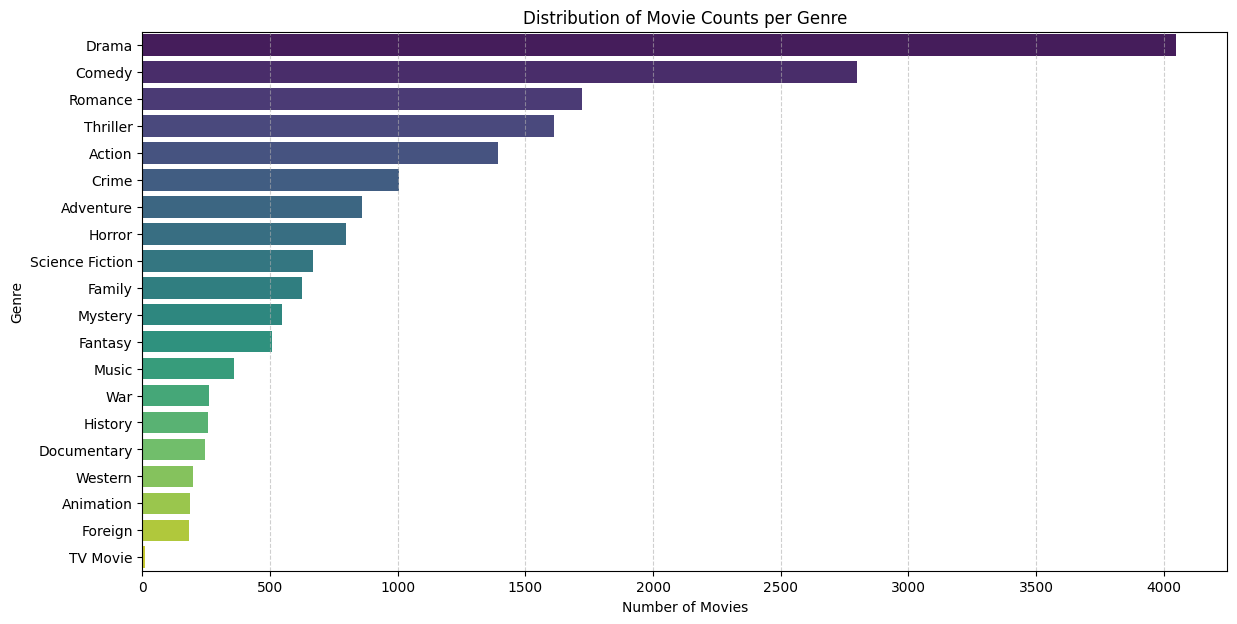

Genre Count Summary:


,Genre,Movie Count
0,Drama,4047
1,Comedy,2798
2,Romance,1722
3,Thriller,1613
4,Action,1391
5,Crime,1006
6,Adventure,860
7,Horror,799
8,Science Fiction,667
9,Family,627


In [180]:
import matplotlib.pyplot as plt
import seaborn as sns

if 'df' in locals() and 'cleaned_genres' in df.columns:
    # Explode the genres list to have one row per genre per movie
    genre_counts_df = df.explode('cleaned_genres')

    # Calculate counts
    genre_counts = genre_counts_df['cleaned_genres'].value_counts().reset_index()
    genre_counts.columns = ['Genre', 'Movie Count']

    # Visualization
    plt.figure(figsize=(14, 7))
    sns.barplot(data=genre_counts, x='Movie Count', y='Genre', palette='viridis')
    plt.title('Distribution of Movie Counts per Genre')
    plt.xlabel('Number of Movies')
    plt.ylabel('Genre')
    plt.grid(axis='x', linestyle='--', alpha=0.6)
    plt.show()

    print("Genre Count Summary:")
    display(genre_counts)
else:
    print("The expected data is not available.")

In [ ]:
if 'df' in locals():
    target_titles = ['Gloria', 'Wuthering Heights']
    ratings_comparison = df[df['title'].isin(target_titles)][['title', 'vote_average']].sort_values(by='title')
    print('Ratings Comparison:')
    display(ratings_comparison)
else:
    print('DataFrame df not found.')

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

if 'df' in locals() and 'cleaned_genres' in df.columns:
    # Filter for movies with recorded revenue > 0 and belonging to target genres
    mask = df['cleaned_genres'].apply(lambda x: any(g in x for g in ['Action', 'Science Fiction']))
    dist_rev_df = df[mask & (df['revenue'] > 0)].copy()

    # Explode the genres for accurate categorization
    dist_rev_exploded = dist_rev_df.explode('cleaned_genres')
    dist_rev_exploded = dist_rev_exploded[dist_rev_exploded['cleaned_genres'].isin(['Action', 'Science Fiction'])]

    plt.figure(figsize=(12, 6))
    sns.boxplot(data=dist_rev_exploded, x='revenue', y='cleaned_genres', palette='viridis')

    plt.title('Revenue Distribution: Action vs. Science Fiction')
    plt.xlabel('Revenue (USD)')
    plt.ylabel('Genre')
    plt.grid(axis='x', linestyle='--', alpha=0.6)
    plt.show()

    # Summary statistics
    rev_stats = dist_rev_exploded.groupby('cleaned_genres')['revenue'].describe()[['count', 'mean', '50%', 'max']]
    print('Revenue Summary Statistics:')
    display(rev_stats.style.format('${:,.0f}'))
else:
    print('DataFrame or cleaned_genres column not found.')

In [ ]:
if 'df' in locals() and 'cleaned_genres' in df.columns:
    # Filter for movies with valid revenue data
    rev_df = df[df['revenue'] > 0]

    scifi_avg_rev = rev_df[rev_df['cleaned_genres'].apply(lambda x: 'Science Fiction' in x)]['revenue'].mean()
    action_avg_rev = rev_df[rev_df['cleaned_genres'].apply(lambda x: 'Action' in x)]['revenue'].mean()

    revenue_comp = pd.DataFrame({
        'Genre': ['Science Fiction', 'Action'],
        'Average Revenue': [scifi_avg_rev, action_avg_rev]
    })

    print('Average Revenue Comparison: Sci-Fi vs. Action')
    display(revenue_comp.style.format({'Average Revenue': '${:,.2f}'}))

    # Visualization
    plt.figure(figsize=(8, 5))
    sns.barplot(data=revenue_comp, x='Genre', y='Average Revenue', palette='viridis')
    plt.title('Average Revenue: Science Fiction vs. Action')
    plt.ylabel('Revenue (USD)')
    plt.show()
else:
    print('DataFrame or cleaned_genres column not found.')

In [ ]:
from collections import Counter

if 'df' in locals() and 'cleaned_genres' in df.columns:
    # Flatten the list of genres and count occurrences
    all_genres = [genre for sublist in df['cleaned_genres'] for genre in sublist]
    genre_counts = Counter(all_genres).most_common(5)

    print('Top 5 Most Frequent Genres:')
    for genre, count in genre_counts:
        print(f'{genre}: {count}')
else:
    print("DataFrame or 'cleaned_genres' column not found.")

In [ ]:
if 'df' in locals():
    print('Raw Genres Column Info:')
    df.info()
    print('\nFirst 10 values in the Genres column:')
    display(df['genres'].head(10))

    # Check unique values to identify common formats
    print('\nSample of unique values (first 5):')
    print(df['genres'].unique()[:5])
else:
    print("DataFrame 'df' not found. Please run the data loading cell first.")

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

if 'df_budget_exploded' in locals():
    # Filter for the two target genres
    dist_df = df_budget_exploded[df_budget_exploded['cleaned_genres'].isin(['Action', 'Science Fiction'])]

    plt.figure(figsize=(12, 6))
    sns.boxplot(data=dist_df, x='budget', y='cleaned_genres', palette='magma')

    plt.title('Budget Distribution: Action vs. Science Fiction')
    plt.xlabel('Budget (USD)')
    plt.ylabel('Genre')
    plt.grid(axis='x', linestyle='--', alpha=0.6)
    plt.show()

    # Descriptive stats for both
    stats = dist_df.groupby('cleaned_genres')['budget'].describe()[['count', 'mean', 'std', 'min', '50%', 'max']]
    print('Detailed Budget Statistics:')
    display(stats.style.format('${:,.0f}'))
else:
    print('Exploded budget DataFrame not found.')

In [ ]:
if 'df_budget_exploded' in locals():
    scifi_avg_budget = df_budget_exploded[df_budget_exploded['cleaned_genres'] == 'Science Fiction']['budget'].mean()
    action_avg_budget = df_budget_exploded[df_budget_exploded['cleaned_genres'] == 'Action']['budget'].mean()

    budget_comparison = pd.DataFrame({
        'Genre': ['Science Fiction', 'Action'],
        'Average Budget': [scifi_avg_budget, action_avg_budget]
    })

    print('Average Budget Comparison: Sci-Fi vs. Action')
    display(budget_comparison.style.format({'Average Budget': '${:,.2f}'}))

    # Visualization
    plt.figure(figsize=(8, 5))
    sns.barplot(data=budget_comparison, x='Genre', y='Average Budget', palette='magma')
    plt.title('Average Budget: Science Fiction vs. Action')
    plt.ylabel('Budget (USD)')
    plt.show()
else:
    print('Exploded budget DataFrame not found. Please run the budget analysis cell first.')

In [ ]:
if 'df' in locals() and 'cleaned_genres' in df.columns:
    # Get top 10 Science Fiction by revenue
    top_10_scifi_rev = df[df['cleaned_genres'].apply(lambda x: 'Science Fiction' in x)].sort_values(by='revenue', ascending=False).head(10)[['title', 'revenue', 'vote_average']]

    # Get top 10 Action by revenue
    top_10_action_rev = df[df['cleaned_genres'].apply(lambda x: 'Action' in x)].sort_values(by='revenue', ascending=False).head(10)[['title', 'revenue', 'vote_average']]

    print('--- Top 10 Highest-Grossing Science Fiction Movies ---')
    display(top_10_scifi_rev.style.format({'revenue': '${:,.0f}'}))

    print('\n--- Top 10 Highest-Grossing Action Movies ---')
    display(top_10_action_rev.style.format({'revenue': '${:,.0f}'}))

    # Check for overlapping titles
    scifi_titles = set(top_10_scifi_rev['title'])
    action_titles = set(top_10_action_rev['title'])
    overlap = scifi_titles.intersection(action_titles)

    print(f'\nMovies appearing in both Top 10 lists: {list(overlap) if overlap else "None"}')
else:
    print('DataFrame or cleaned_genres column not found.')

In [ ]:
if 'df' in locals() and 'cleaned_genres' in df.columns:
    # Filter for Science Fiction and sort by popularity
    top_10_scifi = df[df['cleaned_genres'].apply(lambda x: 'Science Fiction' in x)].sort_values(by='popularity', ascending=False).head(10)

    print('Top 10 Most Popular Science Fiction Movies:')
    display(top_10_scifi[['title', 'popularity', 'vote_average', 'release_date']])
else:
    print('DataFrame or cleaned_genres column not found.')

In [ ]:
if 'df' in locals():
    top_pop_overall = df.sort_values(by='popularity', ascending=False)[['title', 'popularity', 'vote_average', 'release_date']].head(10)
    print('Top 10 Most Popular Movies Overall:')
    display(top_pop_overall)
else:
    print('DataFrame df not found.')

In [ ]:
if 'df' in locals():
    print('Popularity Column Summary Statistics:')
    display(df['popularity'].describe())
    print('\nFirst 10 values in Popularity column:')
    display(df['popularity'].head(10))
else:
    print("DataFrame 'df' not found. Please run the data loading cell first.")

In [ ]:
if 'scifi_df' in locals():
    top_5_popular_scifi = scifi_df.sort_values(by='popularity', ascending=False)[['title', 'popularity', 'vote_average', 'release_date']].head(5)
    print('Top 5 Most Popular Science Fiction Movies:')
    display(top_5_popular_scifi)
else:
    print('Science Fiction DataFrame not found. Please run the Sci-Fi analysis cell first.')

In [ ]:
if 'top_5_overall' in locals() and 'star_wars_data' in locals():
    # Prepare Star Wars data in a similar format
    sw_summary = pd.DataFrame([{
        'title': star_wars_data['title'],
        'revenue': star_wars_data['revenue'],
        'vote_average': star_wars_data['vote_average'],
        'release_date': star_wars_data['release_date']
    }])

    # Combine with top 5
    revenue_comparison = pd.concat([top_5_overall, sw_summary]).drop_duplicates(subset=['title'])

    print('Star Wars vs. Overall Highest-Grossing Movies:')
    display(revenue_comparison.style.format({'revenue': '${:,.0f}'}))

    # Plotting Comparison
    plt.figure(figsize=(12, 6))
    sns.barplot(data=revenue_comparison.sort_values(by='revenue', ascending=False),
                x='revenue', y='title', palette='viridis')
    plt.title('Revenue Comparison: Star Wars vs. Overall Top Earners')
    plt.xlabel('Total Revenue (USD)')
    plt.show()
else:
    print('Required data not found. Please run the top-grossing and Star Wars analysis cells first.')

In [ ]:
if 'scifi_df' in locals():
    # Extract Star Wars data
    star_wars_data = scifi_df[scifi_df['title'] == 'Star Wars'].iloc[0]

    print('--- Star Wars Metadata Deep Dive ---')
    print(f"Title: {star_wars_data['title']}")
    print(f"User Rating: {star_wars_data['vote_average']}")
    print(f"Popularity Score: {star_wars_data['popularity']:.2f}")
    print(f"Revenue: ${star_wars_data['revenue']:,.0f}")
    print(f"Budget: ${star_wars_data['budget']:,.0f}")
    print(f"Runtime: {star_wars_data['runtime']} minutes")
    print(f"Overview: {star_wars_data['overview']}")

    # Contextual comparison
    avg_scifi_pop = scifi_df['popularity'].mean()
    print(f'\nPopularity vs. Genre Average: {star_wars_data["popularity"] / avg_scifi_pop:.1f}x higher than average.')
else:
    print('Science Fiction DataFrame not found.')

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

if 'top_5_popular_scifi' in locals():
    plt.figure(figsize=(10, 6))
    # Sort by rating for a clearer comparison
    plot_df = top_5_popular_scifi.sort_values(by='vote_average', ascending=False)

    sns.barplot(data=plot_df, x='vote_average', y='title', palette='magma')

    plt.title('User Ratings: Top 5 Most Popular Sci-Fi Movies')
    plt.xlabel('Vote Average (0-10)')
    plt.ylabel('Movie Title')
    plt.xlim(0, 10)
    plt.grid(axis='x', linestyle='--', alpha=0.6)

    # Add value labels
    for i, val in enumerate(plot_df['vote_average']):
        plt.text(val + 0.1, i, f'{val:.1f}', va='center', fontweight='bold')

    plt.show()
else:
    print('Top 5 Sci-Fi data not found. Please run the popularity analysis cell first.')

In [ ]:
if 'scifi_df' in locals():
    top_5_popular_scifi = scifi_df.sort_values(by='popularity', ascending=False)[['title', 'popularity', 'vote_average', 'release_date']].head(5)
    print('Top 5 Most Popular Science Fiction Movies:')
    display(top_5_popular_scifi)
else:
    print('Science Fiction DataFrame not found. Please run the Sci-Fi analysis cell first.')

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

if 'scifi_df' in locals():
    # Select relevant numeric factors for Sci-Fi
    factors_df = scifi_df[['vote_average', 'popularity', 'runtime', 'budget', 'revenue']].dropna()

    # Calculate the correlation matrix
    corr_matrix = factors_df.corr()

    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
    plt.title('Correlation Heatmap: Factors Affecting Sci-Fi Ratings')
    plt.show()

    # Specifically looking at the correlation with vote_average
    rating_corrs = corr_matrix['vote_average'].sort_values(ascending=False)
    print('Correlation of various factors with Sci-Fi Ratings:')
    display(rating_corrs)
else:
    print('Science Fiction DataFrame not found. Please run the Sci-Fi budget analysis first.')

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

if 'df' in locals() and 'cleaned_genres' in df.columns:
    # Filter for Science Fiction movies with valid budget and revenue
    scifi_df = df[(df['cleaned_genres'].apply(lambda x: 'Science Fiction' in x)) & (df['budget'] > 0)]

    plt.figure(figsize=(10, 6))
    sns.regplot(data=scifi_df, x='budget', y='vote_average',
                scatter_kws={'alpha':0.5, 'color':'purple'},
                line_kws={'color':'red'})

    plt.title('Science Fiction: Budget vs. User Rating')
    plt.xlabel('Budget (USD)')
    plt.ylabel('Vote Average (0-10)')
    plt.grid(True, linestyle='--', alpha=0.6)

    # Calculate correlation
    correlation = scifi_df['budget'].corr(scifi_df['vote_average'])
    print(f'Correlation between Budget and Rating for Sci-Fi: {correlation:.2f}')

    plt.show()
else:
    print('DataFrame or cleaned_genres column not found.')

In [ ]:
if 'df_budget_exploded' in locals():
    # Define our top-rated and low-rated groups from previous results
    top_rated_genres = ['Crime', 'Drama']
    low_rated_genres = ['Science Fiction', 'Horror']

    budget_comparison_data = []

    for genre in top_rated_genres + low_rated_genres:
        subset = df_budget_exploded[df_budget_exploded['cleaned_genres'] == genre]
        budget_comparison_data.append({
            'Genre': genre,
            'Average Budget': subset['budget'].mean(),
            'Group': 'Top Rated' if genre in top_rated_genres else 'Low Rated'
        })

    budget_rating_df = pd.DataFrame(budget_comparison_data)

    print('Budget Comparison: Top Rated vs. Low Rated Genres')
    display(budget_rating_df.style.format({'Average Budget': '${:,.2f}'}))

    # Visualization
    plt.figure(figsize=(10, 6))
    sns.barplot(data=budget_rating_df, x='Genre', y='Average Budget', hue='Group', palette='coolwarm')
    plt.title('Average Budget: High-Rated vs. Low-Rated Genres')
    plt.ylabel('Average Budget (USD)')
    plt.show()
else:
    print('Exploded budget DataFrame not found. Please run the budget analysis cell first.')

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

if 'df' in locals() and 'cleaned_genres' in df.columns:
    # Define common genres for comparison
    target_genres = ['Drama', 'Comedy', 'Romance', 'Thriller', 'Action', 'Science Fiction', 'Horror', 'Adventure', 'Crime']
    genre_data = []

    for genre in target_genres:
        # Filter rows where the genre is in the cleaned_genres list
        subset = df[df['cleaned_genres'].apply(lambda x: genre in x)]
        if not subset.empty:
            genre_data.append({
                'Genre': genre,
                'Average Rating': subset['vote_average'].mean(),
                'Movie Count': len(subset)
            })

    # Create a summary DataFrame and sort by Average Rating
    genre_comparison_df = pd.DataFrame(genre_data).sort_values(by='Average Rating', ascending=False)

    print('Average Ratings and Movie Counts by Genre:')
    display(genre_comparison_df)

    # Plotting
    plt.figure(figsize=(12, 6))
    sns.barplot(data=genre_comparison_df, x='Average Rating', y='Genre', palette='viridis')
    plt.title('Average User Rating Across Different Genres')
    plt.xlabel('Average Vote Rating (0-10)')
    plt.ylabel('Genre')
    plt.grid(axis='x', linestyle='--', alpha=0.6)
    plt.show()
else:
    print('DataFrame or cleaned_genres column not found. Please run the data cleaning cell first.')

In [ ]:
if 'top_5_overall' in locals() and 'top_5_action_revenue' in locals():
    print('--- Top 5 Movies Overall ---')
    display(top_5_overall.style.format({'revenue': '${:,.0f}'}))

    print('\n--- Top 5 Action Movies ---')
    display(top_5_action_revenue.style.format({'revenue': '${:,.0f}'}))

    # Identifying overlap
    overall_titles = set(top_5_overall['title'])
    action_titles = set(top_5_action_revenue['title'])
    overlap = overall_titles.intersection(action_titles)

    print(f'\nMovies appearing in both lists: {list(overlap) if overlap else "None"}')
else:
    print('One or both top 5 DataFrames were not found. Please run the revenue analysis cells first.')

In [ ]:
if 'df' in locals():
    top_5_overall = df.sort_values(by='revenue', ascending=False)[['title', 'revenue', 'vote_average', 'release_date']].head(5)
    print('Top 5 Highest-Grossing Movies Overall:')
    display(top_5_overall.style.format({'revenue': '${:,.0f}'}))
else:
    print('DataFrame df not found.')

In [ ]:
if 'df' in locals() and 'cleaned_genres' in df.columns:
    # Filter for Action movies with revenue > 0
    action_grossing = df[(df['cleaned_genres'].apply(lambda x: 'Action' in x)) & (df['revenue'] > 0)]

    # Sort by revenue descending and pick top 5
    top_5_action_revenue = action_grossing.sort_values(by='revenue', ascending=False)[['title', 'revenue', 'vote_average', 'release_date']].head(5)

    print('Top 5 Highest-Grossing Action Movies:')
    display(top_5_action_revenue.style.format({'revenue': '${:,.0f}'}))
else:
    print('DataFrame or cleaned_genres column not found.')

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

if 'budget_comp' in locals():
    plt.figure(figsize=(8, 6))
    sns.barplot(data=budget_comp, x='Genre', y='Average Budget', palette='coolwarm')

    plt.title('Average Movie Budget: Action vs. Drama')
    plt.ylabel('Average Budget (USD)')
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    # Formatting y-axis to show millions
    from matplotlib.ticker import FuncFormatter
    def millions(x, pos):
        return f'${x*1e-6:.1f}M'
    plt.gca().yaxis.set_major_formatter(FuncFormatter(millions))

    # Adding value labels on top of bars
    for i, row in budget_comp.iterrows():
        plt.text(i, row['Average Budget'] + 1000000, f"${row['Average Budget']*1e-6:.1f}M",
                 ha='center', fontsize=12, fontweight='bold')

    plt.show()
else:
    print('The budget_comp DataFrame was not found. Please run the budget comparison cell first.')

In [ ]:
if 'df_budget_exploded' in locals():
    action_budget_avg = df_budget_exploded[df_budget_exploded['cleaned_genres'] == 'Action']['budget'].mean()
    drama_budget_avg = df_budget_exploded[df_budget_exploded['cleaned_genres'] == 'Drama']['budget'].mean()

    print(f'Average Budget for Action: ${action_budget_avg:,.2f}')
    print(f'Average Budget for Drama: ${drama_budget_avg:,.2f}')

    budget_comp = pd.DataFrame({
        'Genre': ['Action', 'Drama'],
        'Average Budget': [action_budget_avg, drama_budget_avg]
    })
    display(budget_comp.style.format({'Average Budget': '${:,.2f}'}))
else:
    print('Exploded budget DataFrame not found. Please run the budget analysis cell first.')

In [ ]:
if 'budget_summary' in locals():
    print('Budget Summary Statistics by Genre:')
    display(budget_summary.style.format('${:,.0f}'))
else:
    print('The budget_summary DataFrame was not found. Please run the budget analysis cell first.')

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

if 'df' in locals() and 'cleaned_genres' in df.columns:
    # Explode the genres so each genre has its own row for budget analysis
    df_budget_exploded = df.explode('cleaned_genres')

    # Filtering for rows with budget > 0 to see actual investment distribution
    df_budget_exploded = df_budget_exploded[df_budget_exploded['budget'] > 0]

    # Identify the top 15 most common genres in the dataset
    top_15_genres = df_budget_exploded['cleaned_genres'].value_counts().head(15).index
    df_top_budgets = df_budget_exploded[df_budget_exploded['cleaned_genres'].isin(top_15_genres)]

    plt.figure(figsize=(14, 8))
    sns.boxplot(data=df_top_budgets, x='budget', y='cleaned_genres', palette='coolwarm')

    plt.title('Distribution of Movie Budgets by Genre (Top 15 Most Common)')
    plt.xlabel('Budget (USD)')
    plt.ylabel('Genre')
    plt.grid(axis='x', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

    # Summary statistics table
    budget_summary = df_top_budgets.groupby('cleaned_genres')['budget'].agg(['count', 'median', 'mean']).sort_values(by='median', ascending=False)
    print('Budget Summary Statistics by Genre:')
    display(budget_summary.style.format('${:,.0f}'))
else:
    print('DataFrame or cleaned_genres column not found.')

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

if 'comparison' in locals():
    plt.figure(figsize=(8, 6))
    sns.barplot(data=comparison, x='Genre', y='Average Rating', palette='coolwarm')
    plt.title('Average User Rating: Drama vs. Comedy')
    plt.ylabel('Average Vote (0-10)')
    plt.ylim(0, 10)
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    # Adding labels on top of the bars
    for i, row in comparison.iterrows():
        plt.text(i, row['Average Rating'] + 0.2, f"{row['Average Rating']:.2f}",
                 ha='center', fontsize=12, fontweight='bold')

    plt.show()
else:
    print('The comparison DataFrame was not found. Please run the previous cell first.')

In [ ]:
if 'df' in locals() and 'cleaned_genres' in df.columns:
    drama_movies = df[df['cleaned_genres'].apply(lambda x: 'Drama' in x)]
    comedy_movies = df[df['cleaned_genres'].apply(lambda x: 'Comedy' in x)]

    drama_avg = drama_movies['vote_average'].mean()
    comedy_avg = comedy_movies['vote_average'].mean()

    print(f'Average Rating for Drama ({len(drama_movies)} movies): {drama_avg:.2f}')
    print(f'Average Rating for Comedy ({len(comedy_movies)} movies): {comedy_avg:.2f}')

    # Displaying a comparison dataframe
    comparison = pd.DataFrame({
        'Genre': ['Drama', 'Comedy'],
        'Average Rating': [drama_avg, comedy_avg],
        'Movie Count': [len(drama_movies), len(comedy_movies)]
    })
    display(comparison)
else:
    print('DataFrame or cleaned_genres column not found.')

In [ ]:
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

if 'df' in locals() and 'cleaned_genres' in df.columns:
    # Flatten all genres into a single list
    all_genres = [genre for sublist in df['cleaned_genres'] for genre in sublist]
    genre_counts = Counter(all_genres)
    total_movies = len(df)

    # Create a DataFrame for distribution
    dist_data = []
    for genre, count in genre_counts.items():
        dist_data.append({
            'Genre': genre,
            'Count': count,
            'Percentage': (count / total_movies) * 100
        })

    genre_dist_df = pd.DataFrame(dist_data).sort_values(by='Percentage', ascending=False)

    print(f'Genre Distribution across {total_movies} movies:')
    display(genre_dist_df.style.format({'Percentage': '{:.2f}%'}))

    # Visualization of top 20 genres
    plt.figure(figsize=(12, 8))
    sns.barplot(data=genre_dist_df.head(20), x='Percentage', y='Genre', palette='viridis')
    plt.title('Top 20 Genres by Percentage of Total Dataset')
    plt.xlabel('Percentage of Movies (%)')
    plt.ylabel('Genre')
    plt.grid(axis='x', linestyle='--', alpha=0.6)
    plt.show()
else:
    print('DataFrame or cleaned_genres column not found.')

In [ ]:
if 'full_comparison' in locals():
    print('Genre Comparison Summary:')
    display(full_comparison)
else:
    print('The full_comparison DataFrame was not found. Please ensure the comparison cells have been executed.')

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

if 'full_comparison' in locals():
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # Plot 1: Movie Counts
    sns.barplot(data=full_comparison, x='Genre', y='Count', palette='viridis', ax=ax1)
    ax1.set_title('Total Movie Count by Major Genre')
    ax1.set_ylabel('Number of Movies')

    # Plot 2: Average Ratings
    sns.barplot(data=full_comparison, x='Genre', y='Average Rating', palette='magma', ax=ax2)
    ax2.set_title('Average User Rating by Major Genre')
    ax2.set_ylabel('Average Rating (0-10)')
    ax2.set_ylim(0, 10)

    plt.tight_layout()
    plt.show()
else:
    print('The updated comparison data (full_comparison) was not found. Please run the Comedy analysis cell first.')

In [ ]:
if 'df' in locals() and 'cleaned_genres' in df.columns:
    # Filter for Comedy movies
    comedy_movies = df[df['cleaned_genres'].apply(lambda x: 'Comedy' in x)]
    comedy_count = len(comedy_movies)
    comedy_avg = comedy_movies['vote_average'].mean()

    print(f'Genre: Comedy')
    print(f'Count: {comedy_count}')
    print(f'Average Rating: {comedy_avg:.2f}')

    # Comparing with previously calculated stats from comparison_df
    if 'comparison_df' in locals():
        new_row = pd.DataFrame([{'Genre': 'Comedy', 'Count': comedy_count, 'Average Rating': comedy_avg}])
        # Combine existing comparison with Comedy
        full_comparison = pd.concat([comparison_df, new_row], ignore_index=True).sort_values(by='Count', ascending=False)
        print('\nUpdated Comparison of Major Genres:')
        display(full_comparison)

    # Visualization
    plt.figure(figsize=(10, 5))
    sns.barplot(data=full_comparison if 'full_comparison' in locals() else new_row, x='Genre', y='Average Rating', palette='coolwarm')
    plt.title('Average Rating Comparison (Including Comedy)')
    plt.ylim(0, 10)
    plt.show()
else:
    print('DataFrame or cleaned_genres column not found.')

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

if 'df' in locals() and 'cleaned_genres' in df.columns:
    target_genres = ['Drama', 'Action', 'Thriller']
    comparison_data = []

    for g in target_genres:
        subset = df[df['cleaned_genres'].apply(lambda x: g in x)]
        comparison_data.append({
            'Genre': g,
            'Count': len(subset),
            'Average Rating': subset['vote_average'].mean()
        })

    comparison_df = pd.DataFrame(comparison_data)

    print('Comparison of Drama, Action, and Thriller Genres:')
    display(comparison_df)

    # Visualization - Two plots: Count and Rating
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    sns.barplot(data=comparison_df, x='Genre', y='Count', palette='viridis', ax=ax1)
    ax1.set_title('Movie Count Comparison')
    ax1.set_ylabel('Total Number of Movies')

    sns.barplot(data=comparison_df, x='Genre', y='Average Rating', palette='magma', ax=ax2)
    ax2.set_title('Average Rating Comparison')
    ax2.set_ylabel('Average Vote (0-10)')
    ax2.set_ylim(0, 10)

    plt.tight_layout()
    plt.show()
else:
    print('DataFrame or cleaned_genres column not found.')

In [ ]:
import os
if os.path.exists('/content/movies_metadata(dataset1).csv'):
    print('Dataset found in /content/ folder. You are ready to go!')
else:
    print('Dataset not found in /content/. Please upload it using the folder icon in the sidebar.')

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

if 'df' in locals() and 'cleaned_genres' in df.columns:
    # Identify Action and Thriller movies
    action_count = df['cleaned_genres'].apply(lambda x: 'Action' in x).sum()
    thriller_count = df['cleaned_genres'].apply(lambda x: 'Thriller' in x).sum()
    total_movies = len(df)

    # Create a small summary DataFrame
    genre_summary = pd.DataFrame({
        'Genre': ['Action', 'Thriller', 'Other'],
        'Count': [action_count, thriller_count, total_movies - (action_count + thriller_count)]
    })
    genre_summary['Percentage'] = (genre_summary['Count'] / total_movies) * 100

    print(f'Total Movies in Dataset: {total_movies}')
    display(genre_summary)

    # Visualization
    plt.figure(figsize=(8, 5))
    sns.barplot(data=genre_summary[genre_summary['Genre'] != 'Other'], x='Genre', y='Percentage', palette='coolwarm')
    plt.title('Prevalence of Action and Thriller Genres in Full Dataset')
    plt.ylabel('Percentage of Total Movies (%)')
    plt.ylim(0, 30)
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.show()
else:
    print('DataFrame or cleaned_genres column not found.')

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

if 'df' in locals() and 'high_rated_low_votes' in locals():
    # 1. Get distribution for all movies
    all_genres = [g for sublist in df['cleaned_genres'] for g in sublist]
    all_counts = Counter(all_genres)
    total_all = len(df)
    all_dist = {g: (count / total_all) * 100 for g, count in all_counts.items()}

    # 2. Get distribution for high-rated/low-vote outliers
    outlier_genres = [g for sublist in high_rated_low_votes['cleaned_genres'] for g in sublist]
    outlier_counts = Counter(outlier_genres)
    total_outliers = len(high_rated_low_votes)
    outlier_dist = {g: (count / total_outliers) * 100 for g, count in outlier_counts.items()}

    # 3. Combine into a single DataFrame for plotting
    comparison_list = []
    # We'll look at the top 15 genres overall to keep the chart clean
    top_genres = [g for g, c in all_counts.most_common(15)]

    for g in top_genres:
        comparison_list.append({'Genre': g, 'Percentage': all_dist.get(g, 0), 'Group': 'All Movies'})
        comparison_list.append({'Genre': g, 'Percentage': outlier_dist.get(g, 0), 'Group': 'High-Rated Outliers'})

    dist_df = pd.DataFrame(comparison_list)

    # 4. Plot
    plt.figure(figsize=(12, 8))
    sns.barplot(data=dist_df, x='Percentage', y='Genre', hue='Group', palette='muted')
    plt.title('Genre Distribution Comparison: All Movies vs. High-Rated Outliers')
    plt.xlabel('Percentage of Movies in Group (%)')
    plt.ylabel('Genre')
    plt.grid(axis='x', linestyle='--', alpha=0.6)
    plt.show()
else:
    print('Necessary DataFrames (df or high_rated_low_votes) not found.')

In [ ]:
if 'df' in locals():
    # Filtering for high rating (> 8) but low participation (< 10 votes)
    high_rated_low_votes = df[(df['vote_average'] > 8.0) & (df['vote_count'] < 10)]

    print(f'Found {len(high_rated_low_votes)} movies with >8.0 rating and <10 votes.')
    print('\nTop 15 outliers (sorted by rating):')
    display(high_rated_low_votes[['title', 'vote_average', 'vote_count', 'release_date']].sort_values(by='vote_average', ascending=False).head(15))
else:
    print('DataFrame df not found.')

In [ ]:
if 'df' in locals() and 'cleaned_genres' in df.columns:
    # Filter for Action movies
    action_movies = df[df['cleaned_genres'].apply(lambda x: 'Action' in x)]

    # Sort by vote_average descending and get top 10
    # We include vote_count to see the reliability of the score
    top_10_action = action_movies.sort_values(by='vote_average', ascending=False)[['title', 'vote_average', 'vote_count', 'release_date']].head(10)

    print('Top 10 Action Movies by User Rating:')
    display(top_10_action)
else:
    print('DataFrame or cleaned_genres column not found.')

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

if 'df' in locals() and 'cleaned_genres' in df.columns:
    # Filter for Action movies with valid revenue
    action_rev_df = df[(df['cleaned_genres'].apply(lambda x: 'Action' in x)) & (df['revenue'] > 0)]

    plt.figure(figsize=(12, 7))
    sns.regplot(data=action_rev_df, x='revenue', y='vote_average',
                scatter_kws={'alpha':0.5, 'color':'orangered'},
                line_kws={'color':'blue'})

    plt.title('Action Movies: Revenue vs. User Rating')
    plt.xlabel('Revenue (USD)')
    plt.ylabel('Vote Average (0-10)')
    plt.grid(True, linestyle='--', alpha=0.6)

    # Annotate top revenue and top rated
    top_rev = action_rev_df.loc[action_rev_df['revenue'].idxmax()]
    plt.annotate(top_rev['title'], (top_rev['revenue'], top_rev['vote_average']),
                 xytext=(10, 10), textcoords='offset points', fontsize=9, fontweight='bold')

    plt.show()

    correlation = action_rev_df['revenue'].corr(action_rev_df['vote_average'])
    print(f'Correlation between Revenue and Rating for Action movies: {correlation:.2f}')
else:
    print('DataFrame or cleaned_genres column not found.')

In [ ]:
if 'df' in locals():
    top_10_revenue = df.sort_values(by='revenue', ascending=False)[['title', 'revenue', 'vote_average', 'release_date']].head(10)
    print('Top 10 Highest-Revenue Movies:')
    display(top_10_revenue.style.format({'revenue': '${:,.0f}'}))
else:
    print('DataFrame df not found.')

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

if 'df' in locals():
    # Filtering for movies that actually have revenue data > 0
    revenue_df = df[df['revenue'] > 0]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # Histogram for distribution
    sns.histplot(revenue_df['revenue'], bins=50, kde=True, ax=ax1, color='teal')
    ax1.set_title('Distribution of Revenue (Earner Movies Only)')
    ax1.set_xlabel('Revenue (USD)')
    ax1.set_ylabel('Frequency')

    # Boxplot to see outliers
    sns.boxplot(x=revenue_df['revenue'], ax=ax2, color='lightgreen')
    ax2.set_title('Revenue Boxplot (Earner Movies Only)')
    ax2.set_xlabel('Revenue (USD)')

    plt.tight_layout()
    plt.show()

    print(f'Movies with recorded revenue: {len(revenue_df)}')
    print(f'Median Revenue: ${revenue_df["revenue"].median():,.2f}')
    print(f'Average Revenue: ${revenue_df["revenue"].mean():,.2f}')
else:
    print('DataFrame df not found.')

In [ ]:
if 'df' in locals():
    print("Summary Statistics for Numeric Columns:")
    display(df.describe())

    print("\nNon-null counts and Data Types:")
    df.info()
else:
    print("DataFrame 'df' is not defined.")

In [179]:
import pandas as pd
import ast

# 1. Reset the index if it's currently a MultiIndex to get all data into columns
if isinstance(df.index, pd.MultiIndex):
    df = df.reset_index()

# 2. Filter out rows where 'title' is a parsing artifact (like 'False' or a number)
def is_valid_title(val):
    s = str(val)
    if s.lower() == 'false' or s.isdigit():
        return False
    return True

df = df[df['title'].apply(is_valid_title)].copy()

# 3. Robustly extract genre names from the JSON-like strings
def extract_genre_names(genre_str):
    try:
        # Handle both list-like strings and direct objects
        genres = ast.literal_eval(str(genre_str))
        return [g['name'] for g in genres if isinstance(g, dict) and 'name' in g]
    except:
        return []

df['cleaned_genres'] = df['genres'].apply(extract_genre_names)

# 4. Ensure numeric columns are properly typed
df['vote_average'] = pd.to_numeric(df['vote_average'], errors='coerce')
df = df.dropna(subset=['title'])

print(f'Cleaned DataFrame Shape: {df.shape}')
display(df[['title', 'cleaned_genres', 'vote_average']].head(10))

Cleaned DataFrame Shape: (7651, 25)


,title,cleaned_genres,vote_average
0,Toy Story,"[Animation, Comedy, Family]",7.7
1,Jumanji,"[Adventure, Fantasy, Family]",6.9
2,Grumpier Old Men,"[Romance, Comedy]",6.5
3,Waiting to Exhale,"[Comedy, Drama, Romance]",6.1
4,Father of the Bride Part II,[Comedy],5.7
5,Heat,"[Action, Crime, Drama, Thriller]",7.7
6,Sabrina,"[Comedy, Romance]",6.2
7,Tom and Huck,"[Action, Adventure, Drama, Family]",5.4
8,Sudden Death,"[Action, Adventure, Thriller]",5.5
9,GoldenEye,"[Adventure, Action, Thriller]",6.6


In [ ]:
if 'crime_movies' in locals():
    # Sort by vote_average ascending and show top 15 lowest
    # Filtering for movies that have at least one vote to avoid showing 0s which might be missing data
    low_rated_crime = crime_movies[crime_movies['vote_average'] > 0].sort_values(by='vote_average', ascending=True)

    print('15 Lowest-Rated Crime Movies (with at least 1 vote):')
    display(low_rated_crime[['title', 'vote_average', 'release_date']].head(15))
else:
    print('Crime movies DataFrame not found. Please run the Crime exploration cell first.')

In [ ]:
if 'df' in locals() and 'cleaned_genres' in df.columns:
    # Filter for Crime movies
    crime_movies = df[df['cleaned_genres'].apply(lambda x: 'Crime' in x)]

    print(f'Total Crime Movies: {len(crime_movies)}')
    print(f"Average Rating for Crime: {crime_movies['vote_average'].mean():.2f}")

    print('\nTop 15 Crime Movies by Vote Average:')
    display(crime_movies.sort_values(by='vote_average', ascending=False)[['title', 'vote_average', 'release_date']].head(15))
else:
    print('DataFrame or cleaned_genres column not found.')

In [ ]:
if 'genre_comparison_df' in locals():
    print('Genre Performance Summary (Sorted by Average Rating):')
    display(genre_comparison_df)
else:
    print('The DataFrame genre_comparison_df was not found. Please ensure the comparison cell was executed.')

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

if 'df' in locals() and 'cleaned_genres' in df.columns:
    # Define common genres for comparison
    target_genres = ['Drama', 'Comedy', 'Romance', 'Thriller', 'Action', 'Science Fiction', 'Horror', 'Adventure', 'Crime']
    genre_data = []

    for genre in target_genres:
        # Filter rows where the genre is in the cleaned_genres list
        subset = df[df['cleaned_genres'].apply(lambda x: genre in x)]
        if not subset.empty:
            genre_data.append({
                'Genre': genre,
                'Average Rating': subset['vote_average'].mean(),
                'Movie Count': len(subset)
            })

    # Create a summary DataFrame and sort by Average Rating
    genre_comparison_df = pd.DataFrame(genre_data).sort_values(by='Average Rating', ascending=False)

    print('Average Ratings and Movie Counts by Genre:')
    display(genre_comparison_df)

    # Plotting
    plt.figure(figsize=(12, 6))
    sns.barplot(data=genre_comparison_df, x='Average Rating', y='Genre', palette='viridis')
    plt.title('Average User Rating Across Different Genres')
    plt.xlabel('Average Vote Rating (0-10)')
    plt.ylabel('Genre')
    plt.grid(axis='x', linestyle='--', alpha=0.6)
    plt.show()
else:
    print('DataFrame or cleaned_genres column not found. Please run the data cleaning cell first.')

In [ ]:
if 'df' in locals() and 'cleaned_genres' in df.columns:
    # Filter for Action movies
    action_movies = df[df['cleaned_genres'].apply(lambda x: 'Action' in x)]

    # Sort by vote_average descending and get top 5
    top_action = action_movies.sort_values(by='vote_average', ascending=False)[['title', 'vote_average', 'release_date']].head(5)

    print('Top 5 Action Movies by Vote Average:')
    display(top_action)
else:
    print('DataFrame or cleaned_genres column not found.')

In [ ]:
if 'df' in locals() and 'cleaned_genres' in df.columns:
    action_movies = df[df['cleaned_genres'].apply(lambda x: 'Action' in x)]
    count = len(action_movies)
    avg_rating = action_movies['vote_average'].mean()

    print(f'Genre: Action')
    print(f'Count: {count}')
    print(f'Average Rating: {avg_rating:.2f}')

    print('\nSample Action Titles:')
    display(action_movies[['title', 'vote_average']].head(5))
else:
    print('DataFrame or cleaned_genres column not found.')

In [ ]:
if 'df' in locals():
    print("DataFrame Column Data Types:")
    display(df.dtypes)

    print("\nSummary of Key Columns:")
    print("- title: The primary title of the movie.")
    print("- cleaned_genres: A clean list of genre names extracted from the raw metadata.")
    print("- overview: A brief plot summary of the movie.")
    print("- vote_average: The average user rating (0-10).")
    print("- release_date: The date the movie was originally released.")
    print("- budget & revenue: Financial data stored as numeric values.")
else:
    print("DataFrame 'df' is not defined.")

In [ ]:
if 'df' in locals() and 'cleaned_genres' in df.columns:
    major_genres = ['Comedy', 'Romance', 'Thriller', 'Action', 'Science Fiction']
    genre_stats = []

    for g in major_genres:
        subset = df[df['cleaned_genres'].apply(lambda x: g in x)]
        genre_stats.append({
            'Genre': g,
            'Count': len(subset),
            'Avg Rating': subset['vote_average'].mean()
        })

    stats_df = pd.DataFrame(genre_stats).sort_values(by='Avg Rating', ascending=False)
    print('Summary Statistics for Other Major Genres:')
    display(stats_df)

    # Display a few examples from the highest-rated major genre found above
    top_genre = stats_df.iloc[0]['Genre']
    print(f'\nSample of top-rated {top_genre} movies:')
    display(df[df['cleaned_genres'].apply(lambda x: top_genre in x)].sort_values(by='vote_average', ascending=False)[['title', 'vote_average']].head(10))
else:
    print('DataFrame or cleaned_genres column not found.')

In [ ]:
if 'df' in locals() and 'cleaned_genres' in df.columns:
    drama_movies = df[df['cleaned_genres'].apply(lambda x: 'Drama' in x)]
    print(f'Found {len(drama_movies)} movies in the Drama genre.')
    print('\nSample of Drama Titles:')
    display(drama_movies[['title', 'vote_average', 'release_date']].head(15))
else:
    print('DataFrame or cleaned_genres column not found. Please ensure the data cleaning cell has been run.')

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

if 'df' in locals() and 'cleaned_genres' in df.columns:
    # Explode the cleaned_genres list so each genre has its own row for the vote_average
    df_exploded = df.explode('cleaned_genres')

    # Use the top 15 genres identified in the previous analysis
    top_15_genres_list = [g for g, c in genre_counts]
    df_top_genres = df_exploded[df_exploded['cleaned_genres'].isin(top_15_genres_list)]

    plt.figure(figsize=(12, 8))
    sns.boxplot(data=df_top_genres, x='vote_average', y='cleaned_genres', palette='mako')
    plt.title('Distribution of Vote Average by Genre (Top 15 Most Common)')
    plt.xlabel('Vote Average')
    plt.ylabel('Genre')
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
else:
    print('Cleaned genres or DataFrame not found. Please ensure the data cleaning and genre exploration cells were run.')

In [ ]:
from collections import Counter
import ast

def get_genre_list(genre_str):
    try:
        return [g['name'] for g in ast.literal_eval(str(genre_str))]
    except:
        return []

# Apply the function and flatten the list of genres
all_genres = [genre for sublist in df['genres'].apply(get_genre_list) for genre in sublist]
genre_counts = Counter(all_genres).most_common(15)

print('Top 15 Most Common Genres:')
for genre, count in genre_counts:
    print(f'{genre}: {count}')

In [ ]:
if 'df' in locals():
    print('Financial Summary Statistics (Budget & Revenue):')
    display(df[['budget', 'revenue']].describe().apply(lambda s: s.apply('{0:.2f}'.format)))
else:
    print('DataFrame df not found.')

In [ ]:
if 'df' in locals():
    print("Summary Statistics for Numeric Columns:")
    display(df.describe())

    print("\nNon-null counts and Data Types:")
    display(df.info())
else:
    print("DataFrame 'df' is not defined.")

In [ ]:
import pandas as pd
import ast

# Reset the index to fix the MultiIndex issue seen in previous cells
if isinstance(df.index, pd.MultiIndex):
    df = df.reset_index()

# Drop rows where the title is clearly a parsing artifact (like 'False' or a pure number)
def is_valid_title(val):
    s = str(val)
    if s.lower() == 'false' or s.isdigit():
        return False
    return True

df = df[df['title'].apply(is_valid_title)]

# Basic cleaning for genres - extracting names from the JSON-like strings
def extract_genre_names(genre_str):
    try:
        genres = ast.literal_eval(str(genre_str))
        return [g['name'] for g in genres]
    except:
        return []

df['cleaned_genres'] = df['genres'].apply(extract_genre_names)

print(f'Cleaned DataFrame Shape: {df.shape}')
display(df[['title', 'cleaned_genres', 'vote_average']].head(10))

In [ ]:
import pandas as pd
import csv

file_path = '/content/movies_metadata(dataset1).csv'

# Re-loading the dataset with robust quoting to fix the alignment shift
df = pd.read_csv(file_path,
                 engine='python',
                 quoting=csv.QUOTE_MINIMAL,
                 on_bad_lines='skip')

# Cleaning column names to remove any accidental quotes
df.columns = [c.replace('"', '').strip() for c in df.columns]

print(f'Data reloaded. New Shape: {df.shape}')
# Check if titles and genres are now correctly aligned
if 'title' in df.columns and 'genres' in df.columns:
    display(df[['title', 'genres', 'vote_average']].head(10))
else:
    print('Columns found:', df.columns.tolist())

In [ ]:
if 'comparison_df' in locals():
    print('Genres column content for duplicate titles:')
    display(comparison_df[['title', 'genres']])
else:
    print('comparison_df not found. Please run the duplicate comparison cells first.')

In [ ]:
if 'comparison_df' in locals():
    print('Tagline column content for duplicate titles:')
    display(comparison_df[['title', 'tagline']])
else:
    print('comparison_df not found. Please run the duplicate comparison cells first.')

In [ ]:
if 'comparison_df' in locals():
    print('Overview column content for duplicate titles:')
    display(comparison_df[['title', 'overview']])
else:
    print('comparison_df not found. Please run the duplicate comparison cells first.')

In [ ]:
if 'comparison_df' in locals():
    print('Overview column content for duplicate titles:')
    display(comparison_df[['title', 'overview']])
else:
    print('comparison_df not found. Please run the duplicate comparison cells first.')

In [ ]:
if 'comparison_df' in locals():
    print('Genres column content for duplicate titles:')
    display(comparison_df[['title', 'genres']])
else:
    print('comparison_df not found. Please run the duplicate comparison cells first.')

In [ ]:
import re
if 'comparison_df' in locals():
    def extract_id(text):
        # Search for the 'id': XXXX pattern
        found = re.search(r"'id':\s*(\d+)", str(text))
        return found.group(1) if found else 'Not Found'

    comparison_df['extracted_id'] = comparison_df['popularity'].apply(extract_id)
    print('Extracted IDs for duplicate titles:')
    display(comparison_df[['title', 'extracted_id', 'vote_average', 'popularity']])
else:
    print('comparison_df not found. Please run the duplicate comparison cells first.')

In [ ]:
if 'comparison_df' in locals():
    print('Detailed comparison of overviews and taglines:')
    for idx, row in comparison_df.iterrows():
        print(f"\n--- Title: {row['title']} (Index: {idx}) ---")
        print(f"Overview: {row['overview']}")
        print(f"Tagline: {row['tagline']}")
        print(f"Metadata/Origin: {row['popularity']}")
else:
    print('comparison_df not found. Please ensure the cell creating comparison_df has been run.')

In [ ]:
if 'df' in locals():
    # Filter for the specific titles
    duplicate_titles = ['Gloria', 'Wuthering Heights']
    comparison_df = df[df['title'].isin(duplicate_titles)].sort_values(by='title')

    print(f"Comparing data for: {duplicate_titles}")
    # Displaying all columns to see where they differ (e.g., vote_average, popularity, or metadata)
    display(comparison_df)
else:
    print('DataFrame df not found.')

In [ ]:
if 'df' in locals():
    # Check for most common titles
    title_counts = df['title'].value_counts().head(20)

    print(f"Total unique titles: {df['title'].nunique()}")
    print('\nTop 20 most frequent titles in the cleaned dataset:')
    print(title_counts)

    # Check for short or unusual titles remaining
    short_titles = df[df['title'].str.len() < 3]['title'].unique()
    if len(short_titles) > 0:
        print('\nVery short titles found:', short_titles)
else:
    print('DataFrame df not found.')

In [ ]:
genre_keywords = ['comedy', 'drama', 'action', 'thriller', 'horror', 'romance', 'animation', 'adventure', 'sci-fi', 'fantasy', 'family']

def find_keywords(text):
    text = str(text).lower()
    found = [word for word in genre_keywords if word in text]
    return found

# Apply to the overview column
df['keywords_found'] = df['overview'].apply(find_keywords)

# Count occurrences
from collections import Counter
all_keywords = [kw for sublist in df['keywords_found'] for kw in sublist]
kw_counts = Counter(all_keywords).most_common()

print('Genre Keywords found in Overviews:')
for kw, count in kw_counts:
    print(f'{kw}: {count}')

print('\nSample matches:')
display(df[df['keywords_found'].map(len) > 0][['title', 'keywords_found']].head(10))

In [ ]:
# Check the raw format of the genres column
print('Raw genres sample:')
display(df['genres'].head())

import ast
from collections import Counter
def clean_genres(x):
    try:
        # Convert string representation of list to actual list and extract names
        genres = ast.literal_eval(x)
        return [i['name'] for i in genres]
    except:
        return []

# Apply cleaning to a copy to explore distribution
genre_list = df['genres'].apply(clean_genres)
all_genres = [genre for sublist in genre_list for genre in sublist]
genre_counts = Counter(all_genres).most_common(20)

print('\nTop 20 Genres found in this column:')
for genre, count in genre_counts:
    print(f'{genre}: {count}')

In [ ]:
if 'cleaned_genre_list' in df.columns:
    # Display rows where we recovered at least one 'name' field
    regex_results = df[df['cleaned_genre_list'].map(len) > 0][['title', 'cleaned_genre_list']].head(10)
    display(regex_results)
else:
    print('The column "cleaned_genre_list" has not been generated yet.')

In [ ]:
# Let's look at the raw content of the first few rows across all columns to find the genre JSON
# We are looking for things like [{'id': 16, 'name': 'Animation'}]
for i in range(5):
    print(f"--- Row {i} Raw Data ---")
    print(df.iloc[i].values)
    print("\n")

In [ ]:
if 'cleaned_genre_list' in df.columns:
    # Filter to rows where we actually found something
    samples = df[df['cleaned_genre_list'].map(len) > 0][['title', 'cleaned_genre_list']].head(15)
    print('Sample of Recovered Metadata:')
    display(samples)
else:
    print('The column "cleaned_genre_list" does not exist yet.')

In [ ]:
import re
from collections import Counter

def regex_extract_genres(row):
    genres = []
    for col in df.columns:
        val = str(row[col])
        # Look for the pattern 'name': 'GenreName'
        found = re.findall(r"'name':\s*'([^']+)'", val)
        if not found:
            # Try with double quotes if single quotes aren't there
            found = re.findall(r'"name":\s*"([^"]+)"', val)
        genres.extend(found)

    # Filter out common false positives from production companies
    exclude = {'English', 'United States of America', 'United Kingdom', 'France', 'Germany'}
    return [g for g in list(set(genres)) if g not in exclude and len(g) < 20]

df['cleaned_genre_list'] = df.apply(regex_extract_genres, axis=1)

all_genres_cleaned = [genre for sublist in df['cleaned_genre_list'] for genre in sublist]
genre_distribution = Counter(all_genres_cleaned).most_common(20)

print(f"Recovered genres for {df['cleaned_genre_list'].apply(lambda x: len(x) > 0).sum()} movies.")
print('\nTop Genres in Cleaned Data:')
for genre, count in genre_distribution:
    print(f'{genre}: {count}')

In [ ]:
if 'df' in locals():
    display(df.head())
else:
    print('DataFrame df not found.')

In [ ]:
if 'df' in locals():
    print("DataFrame Info:")
    df.info()
    print("\nDataFrame Shape:")
    display(df.shape)
else:
    print("DataFrame 'df' is not defined. Please run the data loading cell first.")

In [ ]:
df.head()

In [ ]:
if 'df' in locals():
    print('Current DataFrame Columns:', df.columns.tolist())

import csv
file_path = '/content/movies_metadata(dataset1).csv'
with open(file_path, 'r', encoding='utf-8') as f:
    reader = csv.reader(f)
    header = next(reader)
    first_data_row = next(reader)

print('\nOriginal CSV Headers:', header)
print('\nFirst Row Raw Data:', first_data_row)

In [ ]:
# Check the raw format of the genres column
print('Raw genres sample:')
display(df['genres'].head())

import ast
def clean_genres(x):
    try:
        # Convert string representation of list to actual list and extract names
        genres = ast.literal_eval(x)
        return [i['name'] for i in genres]
    except:
        return []

# Apply cleaning to a copy to explore distribution
genre_list = df['genres'].apply(clean_genres)
all_genres = [genre for sublist in genre_list for genre in sublist]
genre_counts = Counter(all_genres).most_common(20)

print('\nTop 20 Genres:')
for genre, count in genre_counts:
    print(f'{genre}: {count}')

In [ ]:
recommend('Casino', 5)

In [ ]:
import matplotlib.pyplot as plt
from collections import Counter

# Calculate tag lengths
df['tag_length'] = df['tags'].apply(lambda x: len(str(x).split()))

print(f"Average words per tag: {df['tag_length'].mean():.2f}")
print(f"Shortest tag: {df['tag_length'].min()} words")
print(f"Longest tag: {df['tag_length'].max()} words")

# Get most common words
all_words = ' '.join(df['tags']).split()
word_freq = Counter(all_words).most_common(20)

print('\nTop 20 most frequent words in tags:')
for word, freq in word_freq:
    print(f'{word}: {freq}')

# Visualize length distribution
plt.figure(figsize=(10, 5))
df['tag_length'].hist(bins=30, color='skyblue', edgecolor='black')
plt.title('Distribution of Tag Lengths (Word Count)')
plt.xlabel('Number of Words')
plt.ylabel('Number of Movies')
plt.show()

In [ ]:
print('Detailed look at a few tags:')
for i in range(3):
    print(f"\nMovie: {df.iloc[i]['title']}")
    print(f"Tag: {df.iloc[i]['tags'][:300]}...")

In [ ]:
if 'df' in locals():
    display(df.head())
else:
    print('DataFrame df not found.')

In [ ]:
# Check for numeric-looking strings or suspicious values in the title column
print('Total rows in current df:', len(df))

# Identify titles that are purely numeric or very short
suspicious_titles = df[df['title'].str.contains(r'^\d', na=False)]
print(f'Rows with titles starting with numbers: {len(suspicious_titles)}')

print('\nSample of suspicious titles:')
display(suspicious_titles['title'].head(20))

# Check a few rows to see what the other columns look like for these cases
print('\nFull row data for a few suspicious titles:')
display(df[df['title'].str.contains(r'^\d', na=False)].head(5))

In [ ]:
if 'df' in locals():
    print("Columns in DataFrame:")
    print(df.columns)
else:
    print("DataFrame 'df' is not defined. Please run the data loading cell successfully first.")

In [ ]:
df.info()

In [ ]:
df.shape

In [ ]:
df.isnull().sum()

In [ ]:
df = df.reset_index()
# After resetting, we check the new shape and column count to see how index levels were handled
print('New column count after reset:', len(df.columns))
df = df.drop_duplicates().reset_index(drop=True)
print(f'Shape after dropping duplicates: {df.shape}')
display(df.head())

In [ ]:
# Realigning based on the observed structure in DAmkMypQn7to
# In some rows, title is in the 'title' column, in others, it's in the index fragments.
def fix_row(row):
    # If 'title' column has 'False' or a number, look in level_20 or level_8
    if str(row['title']) == 'False' or str(row['title']).isdigit():
        return row['tagline'] if str(row['tagline']) != 'nan' else row['title']
    return row['title']

df['title'] = df.apply(fix_row, axis=1)

# Filter out the rows that are definitely not movies
df = df[df['title'] != 'False']
df = df[~df['title'].str.contains(r'^\d+$', na=False)]

print(f'Realigned DataFrame. Valid rows: {len(df)}')
display(df[['title', 'genres']].head())

In [ ]:
df

In [ ]:
df.isnull().sum()

In [ ]:
# Drop rows where title is 'False' or purely numeric due to misalignment
df = df[df['title'] != 'False']
df = df[~df['title'].str.contains(r'^\d+$|^\d+\.\d+$', na=False)]
df = df.dropna(subset=['title'])
print(f'Rows after filtering out numeric/invalid titles: {len(df)}')

In [ ]:
# Fill missing values to avoid errors during string concatenation
df['overview'] = df['overview'].fillna('')
df['tagline'] = df['tagline'].fillna('')
df['genres'] = df['genres'].fillna('')
print('Missing values filled.')

In [ ]:
df.iloc[0]['genres']


In [ ]:
import ast
def clean_genres(x):
    try:
        # Some rows have the real genre list as a string representation of a list
        if '[' in str(x):
            genres = ast.literal_eval(x)
            return " ".join([i['name'] for i in genres])
        return ""
    except:
        return ""

# Let's try to find the actual genre data which usually looks like a list of dicts
df['genres'] = df['genres'].apply(clean_genres)
print('Attempted to clean genres from current column.')
display(df[['title', 'genres']].head())

In [ ]:
df.head()

In [ ]:
df['tagline'] = df['tagline'].fillna('')

In [ ]:
df.isnull().sum()

In [ ]:
# Create the combined tags column
df['tags'] = df['overview'] + " " + df['genres'] + " " + df['tagline']
display(df[['title', 'tags']].head())

In [ ]:
df.head()

In [ ]:
df['tags'][1]

In [ ]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import re

nltk.download('stopwords')
nltk.download('wordnet')
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [ ]:
nltk.download('stopwords')
nltk.download('wordnet')

In [ ]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [ ]:
def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    words = text.split()
    words = [word for word in words if word not in stop_words]
    words = [lemmatizer.lemmatize(word) for word in words]
    return ' '.join(words)

In [ ]:
# Re-run preprocessing on the cleaned dataset
df['tags'] = df['tags'].fillna('')
df['tags'] = df['tags'].apply(preprocess_text)

from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2), stop_words='english')
tfidf_matrix = tfidf.fit_transform(df['tags'])

# Update indices
indices = pd.Series(df.index, index=df['title']).drop_duplicates()
print(f'TF-IDF matrix updated with shape: {tfidf_matrix.shape}')

In [ ]:
# Reset index and update TF-IDF to ensure alignment
df = df.reset_index(drop=True)
indices = pd.Series(df.index, index=df['title']).drop_duplicates()

from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2), stop_words='english')
tfidf_matrix = tfidf.fit_transform(df['tags'])
print(f'Aligned TF-IDF matrix shape: {tfidf_matrix.shape}')

In [ ]:
indices = pd.Series(df.index,index = df['title']).drop_duplicates()
indices

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2), stop_words='english')
tfidf_matrix = tfidf.fit_transform(df['tags'])
print(f'TF-IDF matrix created with shape: {tfidf_matrix.shape}')

In [ ]:
tfidf_matrix = tfidf.fit_transform(df['tags'])
print(f'TF-IDF matrix created with shape: {tfidf_matrix.shape}')

In [ ]:
if 'df' in locals():
    print(f"Success: 'df' is defined with shape {df.shape}")
    display(df.head(2))
else:
    print("Error: 'df' is still not defined. Please run the data loading and cleaning cells above.")

In [ ]:
tfidf_matrix

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
indices = pd.Series(df.index, index=df['title']).drop_duplicates()

def recommend(title, n=10):
    if title not in indices:
        return 'Movie not found'
    idx = indices[title]
    if isinstance(idx, pd.Series):
        idx = idx.iloc[0]
    sim_scores = cosine_similarity(tfidf_matrix[idx], tfidf_matrix).flatten()
    similar_indices = sim_scores.argsort()[::-1][1:n+1]
    return df['title'].iloc[similar_indices]

In [ ]:
recommend('Toy Story', 5)

In [ ]:
import pickle

pickle.dump(tfidf_matrix,open('tfidf_matrix.pkl','wb'))

pickle.dump(indices,open('indices.pkl','wb'))

df.to_pickle('df.pkl')

pickle.dump(tfidf,open('tfidf.pkl','wb'))

In [ ]:
# Let's check a few valid titles from the dataframe to use for testing
print("Available titles to test:")
print(df['title'].dropna().unique()[:10])